# 31 — Intermediate Fusion (Feature-Level)

Extracts penultimate embeddings from each frozen backbone, concatenates them,
and trains a small MLP classifier on top.

**Pipeline:**
1. Hook the input to the final classification Linear of each trained backbone.
2. Extract embeddings for train / dev / test splits and cache them to disk.
3. Align utterances across modalities and concatenate:
   - **Heavy**: `BERT (768) + wav2vec2 (256) + ViT (768) = 1792-dim`
   - **Light**: `DistilBERT (768) + DistilHuBERT (256) + MobileNet (1024) = 2048-dim`
4. Train a `Linear→BN→ReLU→Dropout → Linear→BN→ReLU→Dropout → Linear(→7)` MLP.
5. Evaluate on the test set.

## Combo selection
Set `COMBO` below to `"heavy"` or `"light"`.

| `COMBO` | Text | Audio | Face |
|---------|------|-------|------|
| `"heavy"` | `bert-base-uncased` | `facebook/wav2vec2-base` | `vit_b_16` |
| `"light"` | `distilbert-base-uncased` | `ntu-spml/distilhubert` | `mobilenet_v3_small` |

Results are saved to `../experiments/fusion/intermediate/<version>/<combo>/`.

**Note:** embeddings are cached per combo; first run extracts them (~1–5 min), subsequent runs load from cache.

In [11]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from src.config import (
    DEVICE, VERSION,
    TRAIN_CSV, DEV_CSV, TEST_CSV,
    AUDIO_TRAIN_DIR, AUDIO_DEV_DIR, AUDIO_TEST_DIR,
    EXP_ROOT, EXP_ROOT_AUDIO, EXP_ROOT_FACE,
)
from src.data.text_preprocessing import load_split, build_label_map
from src.data.audio_preprocessing import load_audio_split
from src.data.face_dataset import load_face_metadata
from src.training.utils import slugify
from src.evaluation.intermediate_fusion import run_intermediate_fusion

# ──────────────────────────────────────────────────────────────────────────────
# COMBO SELECTION — set to "heavy" or "light"
# ──────────────────────────────────────────────────────────────────────────────
COMBO = "heavy"   # <-- change to "light" and re-run for the lightweight models

COMBO_MODELS = {
    "heavy": {
        "text":  "bert-base-uncased",
        "audio": "facebook/wav2vec2-base",
        "face":  "vit_b_16",
    },
    "light": {
        "text":  "distilbert-base-uncased",
        "audio": "ntu-spml/distilhubert",
        "face":  "mobilenet_v3_small",
    },
}

selected = COMBO_MODELS[COMBO]
print(f'Combo : {COMBO}')
print(f'Text  : {selected["text"]}')
print(f'Audio : {selected["audio"]}')
print(f'Face  : {selected["face"]}')
print(f'Device: {DEVICE}')

Combo : heavy
Text  : bert-base-uncased
Audio : facebook/wav2vec2-base
Face  : vit_b_16
Device: cuda


## 1 — Load data

In [12]:
train_text_df = load_split(TRAIN_CSV)
label2id, id2label = build_label_map(train_text_df)
print('Label map:', label2id)

# Audio DataFrames (filename + label)
train_audio_df = load_audio_split(TRAIN_CSV, AUDIO_TRAIN_DIR, label2id=label2id)
dev_audio_df   = load_audio_split(DEV_CSV,   AUDIO_DEV_DIR,   label2id=label2id)
test_audio_df  = load_audio_split(TEST_CSV,  AUDIO_TEST_DIR,  label2id=label2id)

# Face DataFrames (one row per saved face crop)
train_face_df = load_face_metadata('train')
dev_face_df   = load_face_metadata('dev')
test_face_df  = load_face_metadata('test')

print(f'Audio  — train: {len(train_audio_df)}, dev: {len(dev_audio_df)}, test: {len(test_audio_df)}')
print(f'Face   — train: {len(train_face_df)}, dev: {len(dev_face_df)}, test: {len(test_face_df)}')

Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Audio  — train: 9988, dev: 1108, test: 2610
Face   — train: 47800, dev: 5324, test: 12117


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\src\data\face_dataset.py:112: DtypeWarning: Columns (0: total_frames, 1: frame_idx, 2: pred_prob) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(meta_path)


## 2 — Resolve run directories for selected combo

In [13]:
def resolve_run_dir(exp_root, model_name):
    """Return the experiment directory for a specific model, checking it exists."""
    d = os.path.join(exp_root, VERSION, slugify(model_name))
    metrics_path = os.path.join(d, 'eval_metrics.json')
    if not os.path.exists(metrics_path):
        train_path = os.path.join(d, 'train_metrics.json')
        if not os.path.exists(train_path):
            raise FileNotFoundError(f'No metrics found in {d!r}. Run training first.')
        f1 = json.load(open(train_path)).get('best_dev_macro_f1', '?')
        print(f'  {model_name:40s}  best_dev_macro_f1={f1}')
    else:
        f1 = json.load(open(metrics_path)).get('macro_f1', '?')
        print(f'  {model_name:40s}  test_macro_f1={f1}')
    return d

print(f'=== {COMBO.upper()} combo ===')
text_run_dir  = resolve_run_dir(EXP_ROOT,       selected['text'])
audio_run_dir = resolve_run_dir(EXP_ROOT_AUDIO, selected['audio'])
face_run_dir  = resolve_run_dir(EXP_ROOT_FACE,  selected['face'])

print()
print('Text  :', text_run_dir)
print('Audio :', audio_run_dir)
print('Face  :', face_run_dir)

=== HEAVY combo ===
  bert-base-uncased                         test_macro_f1=0.44281023575315775
  facebook/wav2vec2-base                    test_macro_f1=0.25068783470700057
  vit_b_16                                  test_macro_f1=0.238915

Text  : ../experiments/text_unimodal\v1\bert_base_uncased
Audio : ../experiments/audio_unimodal\v1\facebook_wav2vec2_base
Face  : ../experiments/face_unimodal\v1\vit_b_16


## 3 — Run Intermediate Fusion

First run will extract embeddings and cache them to disk (~1–5 min).
Subsequent runs load from cache and go straight to MLP training.

In [14]:
OUTPUT_DIR = f'../experiments/fusion/intermediate/{VERSION}/{COMBO}'
print(f'Output → {OUTPUT_DIR}')

results = run_intermediate_fusion(
    text_run_dir  = text_run_dir,
    audio_run_dir = audio_run_dir,
    face_run_dir  = face_run_dir,

    train_csv_path = TRAIN_CSV,
    dev_csv_path   = DEV_CSV,
    test_csv_path  = TEST_CSV,

    train_audio_df = train_audio_df,
    dev_audio_df   = dev_audio_df,
    test_audio_df  = test_audio_df,

    train_face_df  = train_face_df,
    dev_face_df    = dev_face_df,
    test_face_df   = test_face_df,

    # MLP hyperparameters
    mlp_epochs     = 50,
    mlp_batch_size = 64,
    mlp_lr         = 3e-4,
    mlp_dropout    = 0.4,

    output_dir = OUTPUT_DIR,
    device     = DEVICE,
)

Output → ../experiments/fusion/intermediate/v1/heavy
  Intermediate Fusion — embedding extraction
  Loading cache: text_train
  Loading cache: text_dev
  Loading cache: text_test
  Loading cache: audio_train
  Loading cache: audio_dev
  Loading cache: audio_test
  Loading cache: face_train
  Loading cache: face_dev
  Loading cache: face_test

  Embedding dims : {'text': 768, 'audio': 256, 'face': 768}  →  total = 1792
  Train utterances: 9783   Dev: 1091   Test: 2481

  Training Projection Fusion MLP  (d_proj=128, d_hidden=256)
  MLP params: 334,215
  [Epoch 001/50]  train_loss=1.3993  dev_loss=1.3609  dev_macro_f1=0.4546  (best=0.4546)
  [Epoch 005/50]  train_loss=0.6494  dev_loss=1.4982  dev_macro_f1=0.4613  (best=0.4627)
  [Epoch 010/50]  train_loss=0.6276  dev_loss=1.5328  dev_macro_f1=0.4611  (best=0.4627)
  [Epoch 015/50]  train_loss=0.6139  dev_loss=1.5597  dev_macro_f1=0.4440  (best=0.4627)
  Early stop @ epoch 15 (no improvement for 12 epochs)

  Best dev macro-F1: 0.4627
  Tr

## 4 — Results

In [15]:
tm = results['test_metrics']
print(f'Combo       : {COMBO}')
print(f"Accuracy    : {tm['accuracy']:.4f}")
print(f"Macro F1    : {tm['macro_f1']:.4f}")
print(f"Weighted F1 : {tm['weighted_f1']:.4f}")
print(f"Utterances  : {tm['num_utterances']}")
print(f"Emb dims    : {results['emb_dims']}  → total {sum(results['emb_dims'].values())}")

Combo       : heavy
Accuracy    : 0.6191
Macro F1    : 0.4533
Weighted F1 : 0.6163
Utterances  : 2481
Emb dims    : {'text': 768, 'audio': 256, 'face': 768}  → total 1792


## 5 — Training curve

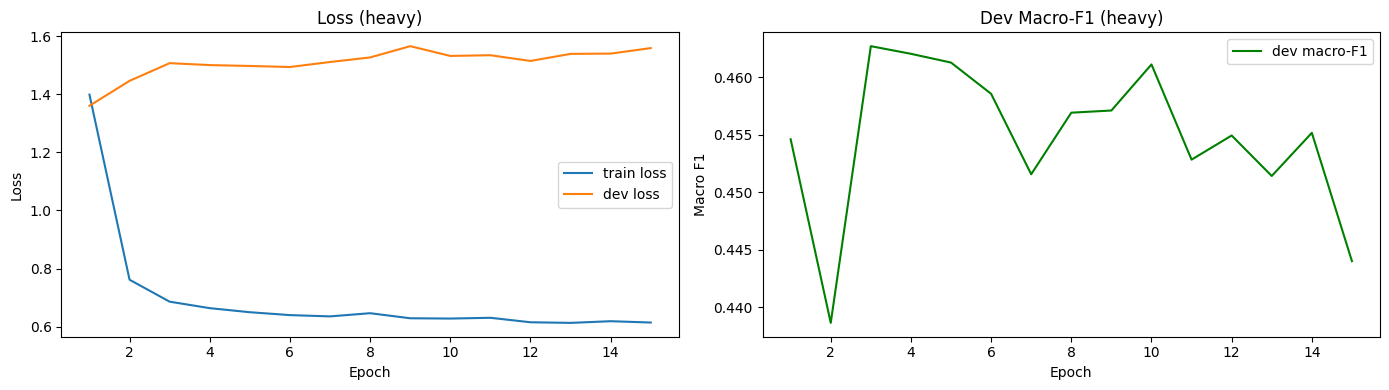

In [16]:
history = pd.DataFrame(results['history'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['epoch'], history['train_loss'], label='train loss')
ax1.plot(history['epoch'], history['dev_loss'],   label='dev loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title(f'Loss ({COMBO})')
ax1.legend()

ax2.plot(history['epoch'], history['dev_macro_f1'], color='green', label='dev macro-F1')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1'); ax2.set_title(f'Dev Macro-F1 ({COMBO})')
ax2.legend()

plt.tight_layout()
plt.show()

## 6 — Per-class breakdown

In [17]:
report = tm['report']
rows = []
for cls in ['Anger','Disgust','Fear','Happiness','Neutral','Sadness','Surprise']:
    if cls in report:
        r = report[cls]
        rows.append({'class': cls,
                     'precision': round(r['precision'], 4),
                     'recall':    round(r['recall'],    4),
                     'f1-score':  round(r['f1-score'],  4),
                     'support':   int(r['support'])})
pd.DataFrame(rows)

,class,precision,recall,f1-score,support
0,Anger,0.5398,0.4756,0.5057,328
1,Disgust,0.2703,0.1515,0.1942,66
2,Fear,0.1905,0.3265,0.2406,49
3,Happiness,0.5878,0.5938,0.5908,389
4,Neutral,0.7426,0.7632,0.7528,1191
5,Sadness,0.3598,0.3089,0.3324,191
6,Surprise,0.5345,0.5805,0.5566,267


## 7 — Confusion matrix

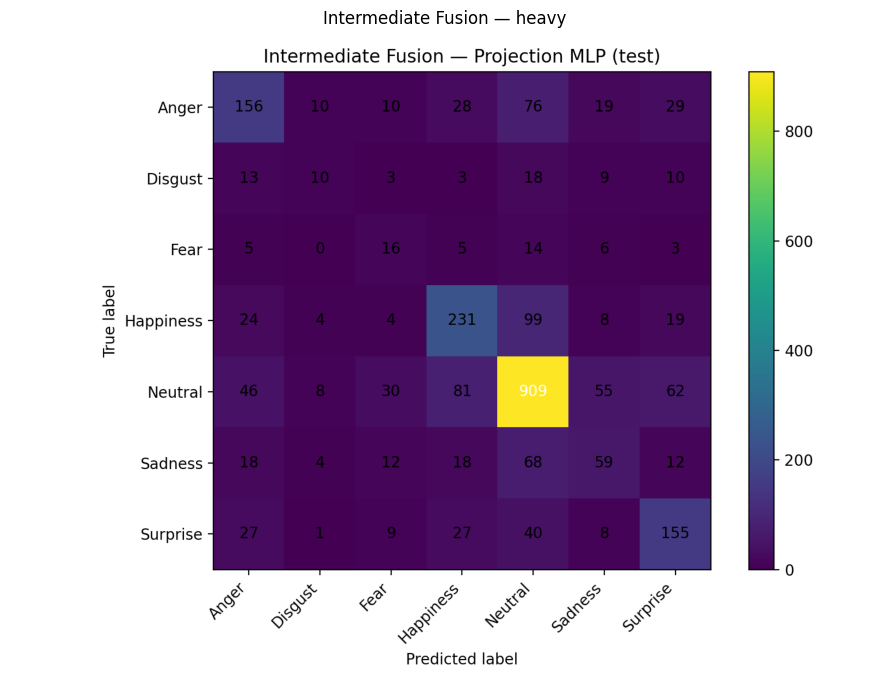

In [18]:
img_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_test.png')
if os.path.exists(img_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
    ax.set_title(f'Intermediate Fusion — {COMBO}')
    plt.tight_layout()
    plt.show()

## 8 — Quick hyperparameter sweep (optional)

Reuse cached embeddings to quickly try different MLP configs.

In [19]:
from src.evaluation.intermediate_fusion import (
    load_embedding_cache, FusionDataset, FusionMLP,
    train_fusion_mlp, evaluate_fusion_mlp,
)

CACHE_DIR = os.path.join(OUTPUT_DIR, 'cache')

sweep_results = []
for dropout in [0.3, 0.4, 0.5]:
    for lr in [1e-3, 3e-4]:
        text_emb_train, text_lbl_train = load_embedding_cache(os.path.join(CACHE_DIR, 'text_train.npz'))
        audio_emb_train, _             = load_embedding_cache(os.path.join(CACHE_DIR, 'audio_train.npz'))
        face_emb_train, _              = load_embedding_cache(os.path.join(CACHE_DIR, 'face_train.npz'))

        text_emb_dev, text_lbl_dev     = load_embedding_cache(os.path.join(CACHE_DIR, 'text_dev.npz'))
        audio_emb_dev, _               = load_embedding_cache(os.path.join(CACHE_DIR, 'audio_dev.npz'))
        face_emb_dev, _                = load_embedding_cache(os.path.join(CACHE_DIR, 'face_dev.npz'))

        text_emb_test, text_lbl_test   = load_embedding_cache(os.path.join(CACHE_DIR, 'text_test.npz'))
        audio_emb_test, _              = load_embedding_cache(os.path.join(CACHE_DIR, 'audio_test.npz'))
        face_emb_test, _               = load_embedding_cache(os.path.join(CACHE_DIR, 'face_test.npz'))

        train_ds = FusionDataset({'text': text_emb_train, 'audio': audio_emb_train, 'face': face_emb_train}, text_lbl_train)
        dev_ds   = FusionDataset({'text': text_emb_dev,   'audio': audio_emb_dev,   'face': face_emb_dev},   text_lbl_dev)
        test_ds  = FusionDataset({'text': text_emb_test,  'audio': audio_emb_test,  'face': face_emb_test},  text_lbl_test)

        mlp = FusionMLP(in_dims=train_ds.dims, dropout=dropout)
        mlp, _ = train_fusion_mlp(mlp, train_ds, dev_ds, epochs=30, lr=lr, device=DEVICE)
        m = evaluate_fusion_mlp(mlp, test_ds, device=DEVICE)

        sweep_results.append({
            'dropout': dropout, 'lr': lr,
            'macro_f1': m['macro_f1'], 'accuracy': m['accuracy']
        })
        print(f'  dropout={dropout}  lr={lr}  macro_f1={m["macro_f1"]:.4f}')

pd.DataFrame(sweep_results).sort_values('macro_f1', ascending=False)


  [Epoch 001/30]  train_loss=1.0444  dev_loss=1.3829  dev_macro_f1=0.4634  (best=0.4634)
  [Epoch 005/30]  train_loss=0.6364  dev_loss=1.4723  dev_macro_f1=0.4601  (best=0.4634)
  [Epoch 010/30]  train_loss=0.6080  dev_loss=1.4859  dev_macro_f1=0.4367  (best=0.4634)
  Early stop @ epoch 13 (no improvement for 12 epochs)

  Best dev macro-F1: 0.4634
  dropout=0.3  lr=0.001  macro_f1=0.4416
  [Epoch 001/30]  train_loss=1.4849  dev_loss=1.3142  dev_macro_f1=0.4301  (best=0.4301)
  [Epoch 005/30]  train_loss=0.6464  dev_loss=1.4487  dev_macro_f1=0.4535  (best=0.4627)
  [Epoch 010/30]  train_loss=0.6012  dev_loss=1.4683  dev_macro_f1=0.4570  (best=0.4627)
  [Epoch 015/30]  train_loss=0.5982  dev_loss=1.4672  dev_macro_f1=0.4563  (best=0.4636)
  [Epoch 020/30]  train_loss=0.5936  dev_loss=1.4845  dev_macro_f1=0.4507  (best=0.4659)
  [Epoch 025/30]  train_loss=0.5836  dev_loss=1.4835  dev_macro_f1=0.4597  (best=0.4659)
  [Epoch 030/30]  train_loss=0.5862  dev_loss=1.4854  dev_macro_f1=0.4580 

,dropout,lr,macro_f1,accuracy
5,0.5,0.0003,0.451027,0.621121
3,0.4,0.0003,0.443506,0.606610
2,0.4,0.0010,0.443088,0.610641
1,0.3,0.0003,0.442383,0.616687
0,0.3,0.0010,0.441582,0.605804
4,0.5,0.0010,0.438399,0.618299
